## **News Topic Classification on Reuters Dataset Using a Feedforward Neural Network**

### **1. Introduction**

I coded this project as part of my self-study to learn neural networks using Francois Chollet's *Deep Learning with Python* (2nd edition). The project below is based on code available in that textbook.

### **2. Defining the Problem**

The Reuters dataset consists of 11,228 newswires from Reuters, labeled over 46 distinct topics. The dataset is split into 8,982 samples for training and 2,246 samples for testing. This is a multi-class classification problem, where each newswire belongs to exactly one of the 46 possible categories. The code builds and trains a feedforward neural network that processes the 8,982 training samples and then evaluates performance on the 2,246 test samples. Each newswire is preprocessed into a vector of word occurrences for use as input to the neural network.

### **3. Assembling, Preparing, and Exploring the Dataset**

Here, I loaded the Reuters dataset from Keras. It split the dataset into training and test sets. The num_words=10000 argument means we’re only keeping the top 10,000 most frequently occurring words in the dataset, so the model trains on the most important vocabulary and ignores rare words that may add noise.

In [ ]:
from tensorflow.keras.datasets import reuters
(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

2110848/2110848 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Here, it prints the number of training samples in the dataset. The Reuters dataset is then split into training and test sets, and here we can see that there are 8,982 articles in the training set.

In [ ]:
>>> len(train_data)

8982

Here, it prints the number of test samples in the dataset. The test set contains 2,246 newswire articles, which will be used to evaluate the model’s performance after training.

In [ ]:
>>> len(test_data)

2246

Here, it displays the 11th training sample from the dataset. Each sample is a list of integers where each number represents a word index in a dictionary of the 10,000 most common words. This shows that the data is already preprocessed as sequences of word indices, not raw text.

In [ ]:
>>> train_data[10]

[1,
 245,
 273,
 207,
 156,
 53,
 74,
 160,
 26,
 14,
 46,
 296,
 26,
 39,
 74,
 2979,
 3554,
 14,
 46,
 4689,
 4329,
 86,
 61,
 3499,
 4795,
 14,
 61,
 451,
 4329,
 17,
 12]

Now I reconstructed the original text of a newswire sample from its sequence of word indices.

In [ ]:
word_index = reuters.get_word_index()
reverse_word_index = dict (
      [(value, key) for (key, value) in word_index.items()])
decoded_newswire_data = " ".join(
      [reverse_word_index.get(i - 3, '?') for i in train_data[0]])

550378/550378 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_labels[10]

np.int64(3)

Here, I defined a function vectorize_sequences that converts a list of integer sequences into a 2D NumPy array of shape (len(sequences), 10000). This one-hot encoding format is used to feed the data into a neural network.

In [ ]:
import numpy as np
def vectorize_sequences(sequences, dimension=10000):
  results = np.zeros((len(sequences), dimension))
  for i, sequence in enumerate(sequences):
    for j in sequence:
        results[i, sequence] = 1.
  return results

Here, I prepared the input data for training and evaluating the model.

In [ ]:
x_train = vectorize_sequences(train_data)
x_test = vectorize_sequences(test_data)

Next, I defined a function to_one_hot that converts integer class labels into one-hot encoded vectors.

In [ ]:
def to_one_hot (labels, dimension=46) :
  results = np.zeros((len(labels), dimension))
  for i, label in enumerate(labels) :
    results[i, label] = 1.
  return results
y_train = to_one_hot(train_labels)
y_test = to_one_hot(test_labels)

Now it imported the to_categorical function from tensorflow.keras.utils and uses it to one-hot encode the train_labels and test_labels.

In [ ]:
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

### **4. Building the Model**

Here I build the model with 3 layers:

First, I made hidden layer with 64 units and ReLU activation. ReLU introduces
non-linearity and helps the model learn complex patterns.

Second, I created another hidden layer, also with 64 units and ReLU activation, allowing the network to deepen its learning.

Lastly, I made an output layer with 46 units (one per class in the Reuters dataset). The softmax activation turns the outputs into a probability distribution over the 46 classes.

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers

model = Sequential([
    layers.Dense(64, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(46, activation="softmax")
])

Here, I compiled the model and adds an optimizer, loss, and metric.

In [ ]:
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

Here, I split the original training dataset into two parts: a partial training set and a validation set. This allows the model to train on one portion of the data while using the validation set to evaluate its performance on unseen data during training.

In [ ]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

### **5. Training the model**

This trained the neural network model using the training data over 20 epochs with a batch size of 512 samples per step. I could see the accuracy improve and the loss get smaller, showing that the model is learning. Unfortunatly, the validations at the starts improved to a high then worsen which demonstrates overfitting.

In [ ]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 70ms/step - accuracy: 0.3892 - loss: 3.1015 - val_accuracy: 0.6250 - val_loss: 1.7936
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.6670 - loss: 1.6231 - val_accuracy: 0.6880 - val_loss: 1.4010
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 48ms/step - accuracy: 0.7310 - loss: 1.2284 - val_accuracy: 0.7220 - val_loss: 1.2132
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.7874 - loss: 0.9725 - val_accuracy: 0.7500 - val_loss: 1.1138
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.8199 - loss: 0.8264 - val_accuracy: 0.7790 - val_loss: 1.0503
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.8526 - loss: 0.6902 - val_accuracy: 0.8020 - val_loss: 0.9779
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 46ms/step - accuracy: 0.8763 - loss: 0.5893 - val_accuracy: 0.8070 - val_loss: 0.9401
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 47ms/step - accuracy: 0.9002 - loss: 0.4984 - val_accuracy: 0.8080 - v

I created a graph to visualize the training and validation loss curves. The graph shows that the training loss decreases with each epoch, which is expected. However, the validation loss reaches a minimum at epoch nine and then starts to increase. This is the point at which overfitting starts to occur.

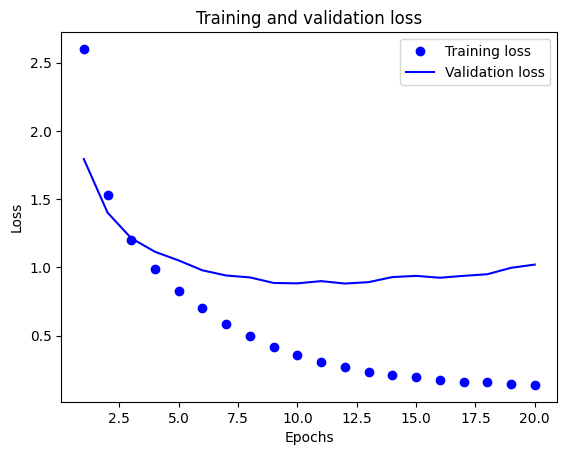

In [ ]:
import matplotlib.pyplot as plt
history_dict = history.history
los_values = history_dict["loss"]
val_loss = history.history["val_loss"]
epochs = range (1, len(los_values) +1 )
plt.plot(epochs, los_values, "bo", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

The training and validation accuracy curves show something similar to the above: validation accuracy peaks at epoch nine and then starts to decrease when overfitting begins.

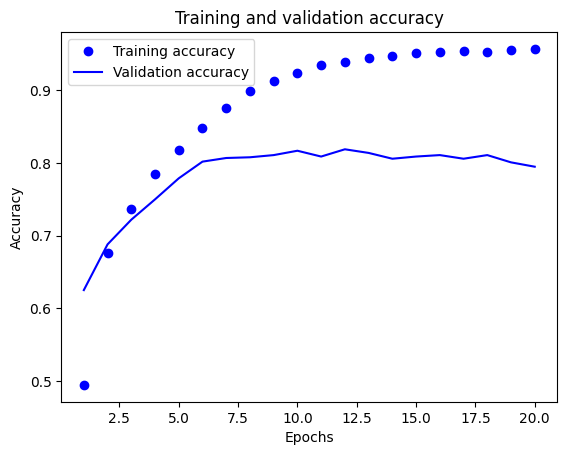

In [ ]:
plt.clf()
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
plt.plot(epochs, acc, "bo", label = "Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### **6. Testing the Model**

This is the final training run on all available training data, followed by evaluation on the test set.

In [ ]:
model.fit(x_train,
          y_train,
          epochs=9,
          batch_size=512)

Epoch 1/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9389 - loss: 0.2302
Epoch 2/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9489 - loss: 0.1776
Epoch 3/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step - accuracy: 0.9523 - loss: 0.1508
Epoch 4/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9594 - loss: 0.1370
Epoch 5/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 39ms/step - accuracy: 0.9541 - loss: 0.1434
Epoch 6/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9577 - loss: 0.1275
Epoch 7/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 39ms/step - accuracy: 0.9560 - loss: 0.1234
Epoch 8/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - accuracy: 0.9620 - loss: 0.1055
Epoch 9/9
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9616 - loss: 0.1155


As a result the accuracy gets a score of 80% which is decent.

In [ ]:
results = model.evaluate(x_test, y_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8051 - loss: 1.0102


In [ ]:
>>> results

[1.0434136390686035, 0.8000890612602234]

Here, I show how the model has improved compared to just ranbomly guessing. In this case, it performed about 17% better than guessing.

In [ ]:
>>> import copy
>>> test_labels_copy = copy.copy(test_labels)
>>> np.random.shuffle(test_labels_copy)
>>> hits_array = np.array(test_labels) == np.array(test_labels_copy)
>>> hits_array.mean()

np.float64(0.1861086375779163)

In [ ]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


This is saying that the first article of predictions array will fit into the 46th category

In [ ]:
>>> predictions[0].shape

(46,)

In [ ]:
>>> np.sum(predictions[0])

np.float32(0.9999998)

In [ ]:
>>> np.argmax(predictions[0])

np.int64(3)